# NICER DATA VIEWER

Optics and Astronomical Technologies

University of Iowa

9 Dec 2025

Jacob Payne

In [1]:
import numpy as np
from mpmath import mp, mpf
from astropy.io import fits
from astropy.table import Table, vstack
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from math import sqrt, ceil, floor
from nicer_data_prep import read_xamin_table, get_evt_data, write_unpack_nicer_sh, write_barycorr_sh, bulk_process, bulk_redo_phase_process
from nicer_helper import make_phaseogram, normalize_phaseogram, plot_phaseogram, combine_phaseograms, get_mission_time, get_mission_end_time, get_obsid_exposure_time, get_obs_interval_time

# Download data

See obsidian note [NICER Data Table of Contents](/Users/jacobpayne/Documents/uiowa_local/OATLAB/OATLAB Vault/Observational Astronomy/NICER Analysis/NICER Data Table of Contents.md) for details

# Select data files

Check out
[Analysis - Recreating Rowan](obsidian://open?vault=OATLAB%20Vault&file=Observational%20Astronomy%2FNICER%20Analysis%2FAnalysis%20-%20Recreating%20Rowan) in Obsidian

In [ ]:
bulk_download_list_J0437 = read_xamin_table('xamin_J0437-4715_exp10000.csv')
print(f'Found {len(bulk_download_list_J0437)} obsids in xamin table')
### Turns out you can sort observations chronologically by sorting by obsid
bulk_download_sorted_J0437 = sorted(bulk_download_list_J0437)

print(bulk_download_sorted_J0437)

In [ ]:
bulk_download_list_J0218 = read_xamin_table('xamin_J0218+4232_exp10000_2.csv')
print(f'Found {len(bulk_download_list_J0218)} obsids in xamin table')
bulk_download_sorted_J0218 = sorted(bulk_download_list_J0218)

In [ ]:
bulk_download_list_J0030 = read_xamin_table('xamin_J0030+0451_exp10000.csv')
print(f'Found {len(bulk_download_list_J0030)} obsids in xamin table')
bulk_download_sorted_J0030 = sorted(bulk_download_list_J0030)

## Parse new data files

In [ ]:
### use write_unpack_nicer_sh AND write_barycorr_sh to create scripts

# write_unpack_nicer_sh(bulk_download_sorted_J0437, target_pulsar='J0437-4715')
# write_barycorr_sh(bulk_download_sorted_J0437, target_pulsar='J0437-4715', verbose=True, use_ra_dec=False)
# write_unpack_nicer_sh(bulk_download_sorted_J0218, target_pulsar='J0218+4232')
write_barycorr_sh(bulk_download_sorted_J0218, target_pulsar='J0218+4232', verbose=True, use_ra_dec=True)

# ### use bulk_process to run both write_unpack_nicer_sh AND write_barycorr_sh scripts
# bulk_process(bulk_download_sorted_J0437, target_pulsar='J0437-4715')
bulk_redo_phase_process(bulk_download_sorted_J0218, target_pulsar='J0218+4232')

# ### use bulk_redo_phase_process to run only the write_barycorr_sh scripts
# bulk_redo_phase_process(bulk_download_sorted_J0437, target_pulsar='J0437-4715')



Remember to call **heainit** to initialize the HEASOFT environment before nicerl2 and other functions are called in the 'process_nicer_<...>' scripts.

# Examples for viewing data in this notebook

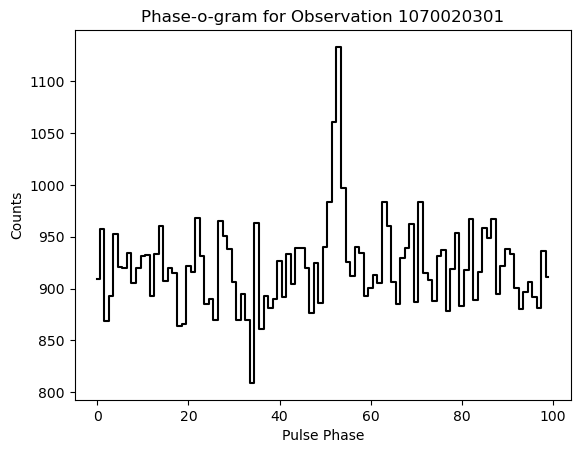

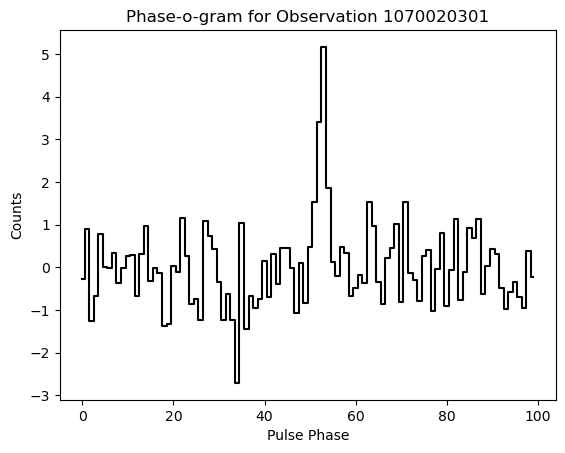

In [2]:
obsids = ['1070020301']
evt_data = get_evt_data(obsids[0])

evt_data # Print the table to see its structure

obsid = "1070020147"

post_fix="_barycorr_PHASE"
event_filename = f"/Users/jacobpayne/Projects/Astronomyprojects/nicer_obs/{obsid}/xti/event_cl/ni1070020147_0mpu7_cl{post_fix}.evt"
hdu_list = fits.open(event_filename, memmap=True)
evt_data = Table(hdu_list[1].data)

phase_o_gram1 = make_phaseogram(evt_data)
plot_phaseogram(phase_o_gram1, obsids[0])
normed_pog = normalize_phaseogram(phase_o_gram1, norm='std')
plot_phaseogram(normed_pog, obsids[0])

## Lomb Scargle Frequency Retrieval


[1.27006588e-06 3.81019764e-06 6.35032939e-06 ... 2.92298677e+00
 2.92298931e+00 2.92299185e+00]


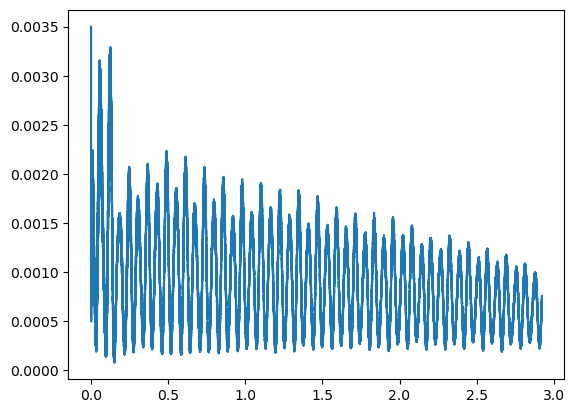

In [6]:
from astropy.timeseries import LombScargle
# provide a histo of events per time

t = evt_data['TIME']
y,bins = np.histogram(evt_data['TIME'], bins=92058)
frequency, power = LombScargle(t, y).autopower()

print(frequency)
plt.plot(frequency, power)

# Analyze a data set

In [ ]:
# obsid_list = sorted(read_xamin_table('xamin_J0437-4715_exp10000.csv'))
# target_pulsar = 'J0437-4715'

obsid_list = sorted(read_xamin_table('xamin_b1821-24_exp10000.csv'))
obsid_list.remove('1070010126') # TIMEOUT
obsid_list.remove('1070010184') # MPU2ERROR
target_pulsar = 'B1821-24'

# obsid_list = sorted(read_xamin_table('xamin_J0218+4232_exp10000_2.csv'))
# target_pulsar = 'J0218+4232'

# obsid_list = sorted(read_xamin_table('xamin_J0030+0451_exp10000.csv'))
# target_pulsar = 'J0030+0451'

# obsid_list = sorted(read_xamin_table('xamin_b1937+21_exp10000.csv'))
# target_pulsar = 'B1937+21'

In [ ]:
# Make a list by including only observations where counts/exposure time < 3
filtered_obsid_list = []

total_exposure = 0
for obsid in obsid_list:
    phase_o_gram = make_phaseogram(get_evt_data(obsid))
    counts = np.sum(phase_o_gram)
    exposure_time = get_obsid_exposure_time(obsid)
    if counts / exposure_time < 3:
        filtered_obsid_list.append(obsid)
        total_exposure += exposure_time
print(f'Filtered out {len(obsid_list) - len(filtered_obsid_list)} of {len(obsid_list)} to get {len(filtered_obsid_list)} good observations with < 3 counts per second')
print(f'Total exposure time of filtered observations: {total_exposure} seconds')

## Diagnostic Plots
1. Plot one observation with error bars.
1. Make a grid of each observation in the data set.
1. Plot total counts versus duration to check average count rate.
1. Plot each phase-o-gram without normailization.
1. Combine all phase-o-grams, and compare to the phase-o-gram of obsids filtered by the coarse count rate cutoff. `filtered_obsid_list`

In [ ]:
obsid = filtered_obsid_list[0]
evt_data = get_evt_data(obsid)
phase = evt_data['PHASE']
phase_o_gram, bin_edges = np.histogram(phase, bins=100)
# plt.plot(phase_o_gram, drawstyle='steps-mid', color='black')
plt.errorbar(range(0,100),phase_o_gram, yerr=np.sqrt(phase_o_gram), drawstyle='steps-mid', color='black', errorevery=1, ecolor='black')
# plt.errorbar(range(0,100),phase_o_gram, yerr=np.sqrt(phase_o_gram),drawstyle='steps-mid', color='red', errorevery=1, data=)
# plt.ylim(-2, max(phase_o_gram)*1.1)
plt.xlabel('Pulse Phase')
plt.ylabel('Counts')
plt.title(f'Phase-o-gram for Observation {obsid}')
plt.show()

In [ ]:
# make a grid of subplots of each observation in the data set

# pick number of rows and columns for subplots

subplot_rows = len(obsid_list)//8+1
subplot_cols = ceil(len(obsid_list)/subplot_rows)

fig, axs = plt.subplots(subplot_rows, subplot_cols, figsize=(15, 8))
fig.suptitle('Phase-o-grams for Each Observation', fontsize=16)
axs = axs.flatten()  # Flatten the 2D array of axes to 1D for easy iteration

# bulk_download_sorted_J0218.remove('6070030697')

for i in range(len(obsid_list)):
    obsid = obsid_list[i]
    # print(f'Observation {i}: obsid {obsid}, exposure time: {get_obsid_exposure_time(obsid)} s')
    
    evt_data = get_evt_data(obsid)

    multi_phase_o_gram = make_phaseogram(evt_data, nbins=100)
    normed_multi_phase_o_gram = normalize_phaseogram(multi_phase_o_gram, norm='std')

    # Plot the phaseogram for each observation
    # INPUT regular or NORMALIZED
    if obsid in filtered_obsid_list:
        axs[i].plot(normed_multi_phase_o_gram, drawstyle='steps-mid', color='black')
    else:
        axs[i].plot(normed_multi_phase_o_gram, drawstyle='steps-mid', color='grey', alpha=0.2)

    # only label the x-axis on the bottom plots
    if i // subplot_cols == subplot_rows - 1:
        axs[i].set_xlabel('Phase')
    # only label the y-axis on the leftmost plots
    if i % subplot_cols == 0:
        axs[i].set_ylabel('σ')
    axs[i].set_title(f"Obs {obsid} \n {np.datetime64(np.datetime64('2014-01-01') + np.timedelta64(int(get_mission_time(obsid)), 's'),'D')}", fontsize=8)
    axs[i].tick_params(axis='both', which='major', labelsize=6)
    # add padding between subplots
    plt.subplots_adjust(hspace=0.5, wspace=0.4)

    # delete the empty subplot(s)
    if i == len(obsid_list) - 1:
        for j in range(i+1, len(axs)):
            fig.delaxes(axs[j])
            # print(f'Deleted unused subplot {j}')


In [ ]:
# make a plot of each observations' Counts vs Exposure time (x=exposure time, y=counts)
fig,axs = plt.subplots(1,2,figsize=(12, 5))
axs[0].set_title('Counts vs Exposure time', fontsize=16)
axs[0].set_xlabel('Exposure Time (s)')
axs[0].set_ylabel('Total Counts')
max_exposure = 0
for i in range(len(obsid_list)):
    axs[0].plot(get_obsid_exposure_time(obsid_list[i]), np.sum(make_phaseogram(get_evt_data(obsid_list[i]))), 'o')
    axs[0].annotate(obsid_list[i], (get_obsid_exposure_time(obsid_list[i]), np.sum(make_phaseogram(get_evt_data(obsid_list[i])))), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
    if get_obsid_exposure_time(obsid_list[i]) > max_exposure:
        max_exposure = get_obsid_exposure_time(obsid_list[i])
# add a line for 3 counts per second
axs[0].plot([5000, max_exposure], [15000, 3*max_exposure], 'r--',alpha=0.5)
axs[0].annotate('3 counts per second', (max_exposure*0.75, 3*max_exposure*0.65), fontsize=10, color='red', alpha=0.5)
axs[0].plot([5000, max_exposure], [25000, 5*max_exposure], 'r--')
axs[0].annotate('5 counts per second', (max_exposure*0.75, 5*max_exposure*1.05), fontsize=10, color='red')

axs[1].set_title('Filtered Counts vs Exposure time', fontsize=16)
axs[1].set_xlabel('Exposure Time (s)')
axs[1].set_ylabel('Total Counts')

for i in range(len(filtered_obsid_list)):
    axs[1].plot(get_obsid_exposure_time(filtered_obsid_list[i]), np.sum(make_phaseogram(get_evt_data(filtered_obsid_list[i]))), 'o')
    axs[1].annotate(filtered_obsid_list[i], (get_obsid_exposure_time(filtered_obsid_list[i]), np.sum(make_phaseogram(get_evt_data(filtered_obsid_list[i])))), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
# add a line for 3 counts per second
axs[1].plot([5000, max_exposure], [15000, 3*max_exposure], 'r--',alpha=0.5)
axs[1].annotate('3 counts per second', (max_exposure*0.75, 3*max_exposure*0.65), fontsize=10, color='red', alpha=0.5)

In [ ]:
#plot multiple phaseograms on a single plot 
fig = plt.plot(figsize=(15, 8))
plt.title('Phase-o-grams', fontsize=16)
plt.xlabel('Phase')
plt.ylabel('Counts')
plt.tick_params(axis='both', which='major', labelsize=6)

for i in range(len(obsid_list)):
    obsid = obsid_list[i]
    evt_data = get_evt_data(obsid)
    phase_o_gram = make_phaseogram(evt_data, nbins=100)
    # normed_pog = normalize_phaseogram(phase_o_gram, norm='counts per second', exposure=get_obsid_exposure_time(obsid[0]))
    if obsid in filtered_obsid_list:
        plt.plot(phase_o_gram, drawstyle='steps-mid')
        plt.annotate(f"Obs {obsid}", xy=(0.8, max(phase_o_gram)*0.9), fontsize=10)
    else:
        plt.plot(phase_o_gram, drawstyle='steps-mid', color='gray', alpha=0.5)

plt.show()

In [ ]:
#plot multiple phaseograms on a single plot for the peak observations
fig = plt.plot(figsize=(15, 8))
plt.title('Phase-o-grams for good observations', fontsize=16)
plt.xlabel('Phase')
plt.ylabel('Standard Deviation')
plt.tick_params(axis='both', which='major', labelsize=6)

all_multi_phase_o_gram = combine_phaseograms(obsid_list)
normed_all_multi_phase_o_gram = normalize_phaseogram(all_multi_phase_o_gram, norm='std')

multi_phase_o_gram = combine_phaseograms(filtered_obsid_list)
normed_multi_phase_o_gram = normalize_phaseogram(multi_phase_o_gram, norm='std')    

plt.plot(normed_all_multi_phase_o_gram, drawstyle='steps-mid', color='red', alpha=0.5, label=f'All {len(obsid_list)} Observations')
plt.plot(normed_multi_phase_o_gram, drawstyle='steps-mid', color='black', label=f'{len(filtered_obsid_list)} Observations with < 3 counts/sec')
plt.legend(loc='center right', fontsize=10)
plt.show()

## Spectral Plots
1. Take the FILTERED obsids and separate out into energy bands for a Rowan2020 style plot.
1. Make a stacked comparison of three energy bands all on one y-axis.
1. Make the Rowan2020 style plot.
1. Variable resolution energy windows.

In [ ]:
### uses FILTERED_OBSID_LIST
# look at observations and build multi_phase_o_grams for each energy window


noise_floor_energy_phase_o_gram = np.zeros(100) # noise floor energy window
first_energy_phase_o_gram = np.zeros(100) # low energy window
second_energy_phase_o_gram = np.zeros(100) # medium energy window 
third_energy_phase_o_gram = np.zeros(100) # high energy window 
noise_ceiling_energy_phase_o_gram = np.zeros(100) # noise ceiling energy window

for obsid in filtered_obsid_list:
    evt_data = get_evt_data(obsid)
    for evt in evt_data:
        energy = evt['PI']
        phase = evt['PHASE']

        if 20 <= energy < 50: #  0.2-0.5 keV
            bin_idx = int(phase * 100) % 100
            noise_floor_energy_phase_o_gram[bin_idx] += 1

        if 50 <= energy < 100: #  0.5-1.0 keV
            bin_idx = int(phase * 100) % 100
            first_energy_phase_o_gram[bin_idx] += 1
            
        elif 100 <= energy < 200: # 1.0-2.0 keV
            bin_idx = int(phase * 100) % 100
            second_energy_phase_o_gram[bin_idx] += 1
            
        elif 200 <= energy < 600: # 2.0-6.0 keV
            bin_idx = int(phase * 100) % 100
            third_energy_phase_o_gram[bin_idx] += 1

        elif energy >= 600: # >6.0 keV
            bin_idx = int(phase * 100) % 100
            noise_ceiling_energy_phase_o_gram[bin_idx] += 1

In [ ]:
# plot the three energy windows on a single plot with a legend
# February Poster style
fig = plt.figure(figsize=(6, 10))
plt.title(f'Phase-o-grams of Pulsar {target_pulsar}', fontsize=16)
plt.xlabel('Phase')
plt.ylabel('Counts')
plt.ylim(0, max(max(first_energy_phase_o_gram), max(second_energy_phase_o_gram), max(third_energy_phase_o_gram))*1.1)
plt.errorbar(range(0,100), first_energy_phase_o_gram, yerr=np.sqrt(first_energy_phase_o_gram), drawstyle='steps-mid', color='blue', label='0.5-1.0 keV', ecolor='black')
plt.errorbar(range(0,100), second_energy_phase_o_gram, yerr=np.sqrt(second_energy_phase_o_gram), drawstyle='steps-mid', color='green', label='1.0-2.0 keV', ecolor='black')
plt.errorbar(range(0,100), third_energy_phase_o_gram, yerr=np.sqrt(third_energy_phase_o_gram), drawstyle='steps-mid', color='red', label='2.0-6.0 keV', ecolor='black')
plt.annotate(f'{total_exposure/1000:.1f} ksec', xy=(10, 2100), bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.show()  

In [ ]:
# plot three subplots stacked vertically
# Rowan2020 style

fig, axs = plt.subplots(3, 1, figsize=(8, 8))
#  remove verticle space between subplots
plt.subplots_adjust(hspace=0.0)
fig.suptitle(f'Phase-o-grams at different Energies of Pulsar {target_pulsar}', fontsize=16)
fig.supxlabel('Phase')
fig.supylabel('Counts')
axs[0].plot(first_energy_phase_o_gram/(total_exposure/100), drawstyle='steps-mid', color='blue')
axs[0].annotate('(0.5-1.0 keV)', xy=(75, 0.75), fontsize=12)
axs[0].set_ylim(0, 1.0)
axs[0].set_xticks([])
axs[1].plot(second_energy_phase_o_gram/(total_exposure/100), drawstyle='steps-mid', color='green')
axs[1].annotate('(1.0-2.0 keV)', xy=(75, 0.75), fontsize=12)
axs[1].set_ylim(0, 1.0)
axs[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8])
axs[1].set_xticks([])
axs[2].plot(third_energy_phase_o_gram/(total_exposure/100), drawstyle='steps-mid', color='red')
axs[2].annotate('(2.0-6.0 keV)', xy=(75, 0.75), fontsize=12)
axs[2].set_ylim(0, 1.0)
axs[2].set_yticks([0, 0.2, 0.4, 0.6, 0.8])
axs[2].set_xticks([])
plt.show()

In [ ]:
### variable resolution energy windows
# look at observations and build multi_phase_o_grams for each 300 eV energy window

#plot multiple phaseograms on a single plot 
fig = plt.plot(figsize=(15, 8))
plt.title(f'Phase-o-gram for {target_pulsar}', fontsize=16)
plt.xlabel('Phase')
plt.ylabel('Counts')
plt.tick_params(axis='both', which='major', labelsize=6)

window = 30 # eV / 10 (e.g. 30 means 300 eV windows)    <-- Input WINDOW SIZE

eV_range = range(20, 1510, window)
data_frames = np.zeros((len(eV_range), 100)) # energy bins, 100 phase bins

for obsid in obsid_list:
    evt_data = get_evt_data(obsid)
    for evt in evt_data:
        energy = evt['PI']
        phase = evt['PHASE']
        data_frames[(energy-20)//window][int(phase * 100) % 100] += 1


for i in range(50, 300, window):
    phase_o_gram = data_frames[(i-20)//window]
    mean = np.mean(phase_o_gram)
    std = np.std(phase_o_gram)
    normed_phase_o_gram = (phase_o_gram - mean) / std
    plt.plot(phase_o_gram, drawstyle='steps-mid',label=f'{i/100}-{(i+window)/100} keV')

plt.legend(loc='upper right', fontsize=8)
plt.show()


In [ ]:
# plot the low energy band phaseogram with error bars
plt.errorbar(range(0,100),first_energy_phase_o_gram, yerr=np.sqrt(first_energy_phase_o_gram),drawstyle='steps-mid', color='black', errorevery=1, ecolor='purple')
plt.xlabel('Pulse Phase')
plt.ylabel('Counts')
plt.title(f'(0.5-2.0 keV) Phase-o-gram with Poisson Error Bars {target_pulsar}')
# 
plt.show()

## Deeper Diagnostics - CHECK THE MATH
1. Print verbose phase calculation, and compare to doing the same math in python.
1. Introduce Bogdanov's razor (16 second window screening).
1. Spectral plot using Bogdanov's razor.

In [ ]:
obsid = filtered_obsid_list[0]
evt_data = get_evt_data(obsid, post_fix='_barycorr_PHASE')
print(f'Event data for ObsID {obsid}:')
evt_data['FT','TSQUARED','FDOTTSQUAREDOVERTWO','FTPLUSFDOTTSQUAREDOVERTWO','PHASE'][0:5].pprint(max_width=-1)
# print(evt_data['FTPLUSFDOTTSQUAREDOVERTWO','PHASE'][0:5])
# print(evt_data['PHASE'][0:5])


# apply this for each time in the astropy table column BARY_REF_TIME:
# mp.dps = 30 # number of sig figs
# f0 = mpf(173.6879456649435)
# f1 = mpf(-1.7283783e-15)

# # f0 = mpf(327.40554427918)
# # f1 = mpf(-1.73511e-13)

from pulsar_dictionary import pulsar_dict

### EDIT THIS LINE TO POINT TO THE TARGET PULSAR
target_pulsar = pulsar_dict[target_pulsar]

f0 = target_pulsar['frequency']
f1 = target_pulsar['f_dot']
print('-'*20)
print('calculating intermediate values')
ft = evt_data['BARY_REF_TIME'].astype(mpf)*f0
t_squared = evt_data['BARY_REF_TIME'].astype(mpf)**2
f_dot_t_squared_over_2 = f1*t_squared/2
added_terms = ft + f_dot_t_squared_over_2
pyphases = added_terms%1
pyphases = pyphases.astype(float)

print(f'Frequency (f0): {f0}')
print(f'Frequency derivative (f1): {f1}')
for i in range(5):
    print(f'ft: {ft[i]:.30}, t**2: {t_squared[i]:.30}, (f1*t**2)/2:{f_dot_t_squared_over_2[i]:.30}, ft+(f1*t**2)/2:{added_terms[i]:.30}, pyphases:{pyphases[i]}')


# print('-'*20)
# print(f'Event, FT, TSQUARED, FDOTTSQUAREDOVERTWO, FTPLUSFDOTTSQUAREDOVERTWO, PHASE, py PHASE')
# for i in range(5):
#     print(f'Event {i}: FT = {evt_data["FT"][i]:.30}, TSQUARED = {evt_data["TSQUARED"][i]:.30}, FDOTTSQUAREDOVERTWO = {evt_data["FDOTTSQUAREDOVERTWO"][i]:.30}, FTPLUSFDOTTSQUAREDOVERTWO = {evt_data["FTPLUSFDOTTSQUAREDOVERTWO"][i]:.30}, PHASE (from evt_data) = {evt_data["PHASE"][i]}, py PHASE = {pyphases[i]}')


### PLOTS

# print('-'*20)
# print('calculating PHASE in python')
# pyphase_o_gram, bin_edges = np.histogram(pyphases, bins=100)
# plot_phaseogram(pyphase_o_gram, obsid)

# print('-'*20)
# print('PHASE from shell')
# phases = evt_data['PHASE']
# phase_o_gram, bin_edges = np.histogram(phases, bins=100)
# plot_phaseogram(phase_o_gram, obsid)

# filtered_py_PHASE = np.zeros(100)
# for obsid in filtered_obsid_list:
#     evt_data = get_evt_data(obsid, post_fix='_barycorr_PHASE')
#     #get only evt_data from the BARY_REF_TIME column where evt_data['PI'] is between 30 and 300
#     mask = (evt_data['PI'] >= 30) & (evt_data['PI'] <= 300)
#     bary_ref_time = evt_data['BARY_REF_TIME'][mask].astype(mpf)
#     calc_PHASE = ((f0 * bary_ref_time) + (f1 * (bary_ref_time **2)/2)) % 1
#     calc_PHASE = calc_PHASE.astype(float)
#     filtered_py_PHASE += np.histogram(calc_PHASE, bins=100)[0]

# plot_phaseogram(filtered_py_PHASE, 'Filtered Observations Combined')

In [ ]:
# # EXPERIMENTAL DATA REDUCTION METHOD FOR J0437-4715
# # filter 16 second windows where the count rate exceeds 3 counts per second

def screen_evt(obsids_plural):
    window_size = 16  # seconds
    count_rate_threshold = 3  # counts per second

    evt_data = get_evt_data(obsid)
    screened_evt_data = evt_data[:0]
    
    interval_time = get_obs_interval_time(obsid)
    num_windows = int(interval_time.astype('int') // window_size)
    t_0 = get_mission_time(obsid)

    for i in range(num_windows):
        start_time = i * window_size + t_0
        end_time = (i + 1) * window_size + t_0
        window_events = evt_data[(evt_data['TIME'] >= start_time) & (evt_data['TIME'] < end_time)]
        if len(window_events) < count_rate_threshold * window_size:  # If count rate is less than 3 counts per second
            screened_evt_data = vstack([screened_evt_data, window_events])
    return screened_evt_data

In [ ]:
### SCREENING WINDOW METHOD
# look at screened observations and build three multi_phase_o_grams for each of three energy windows

low_energy_phase_o_gram = np.zeros(100) # low energy window
medium_energy_phase_o_gram = np.zeros(100) # medium energy window 
high_energy_phase_o_gram = np.zeros(100) # high energy window 

for obsid in obsid_list:
    evt_data = screen_evt(obsid)
    for evt in evt_data:
        energy = evt['PI']
        phase = evt['PHASE']

        if 50 <= energy < 200: #  0.5-2.0 keV
            bin_idx = int(phase * 100) % 100
            low_energy_phase_o_gram[bin_idx] += 1
            
        elif 200 <= energy < 400: # 2.0-4.0 keV
            bin_idx = int(phase * 100) % 100
            medium_energy_phase_o_gram[bin_idx] += 1
            
        elif 400 <= energy < 1200: # 4.0-12.0 keV
            bin_idx = int(phase * 100) % 100
            high_energy_phase_o_gram[bin_idx] += 1

# plot three subplots stacked vertically
fig, axs = plt.subplots(3, 1, figsize=(8, 8))
#  remove verticle space between subplots
plt.subplots_adjust(hspace=0.0)
fig.suptitle('Phase-o-grams for Energy Windows', fontsize=16)
fig.supxlabel('Phase')
fig.supylabel('Counts')
axs[0].plot(low_energy_phase_o_gram, drawstyle='steps-mid', color='blue')
axs[0].annotate('(0.5-2.0 keV)', xy=(75, max(low_energy_phase_o_gram)*0.99), fontsize=12)
axs[0].set_xticks([])
axs[1].plot(medium_energy_phase_o_gram, drawstyle='steps-mid', color='green')
axs[1].annotate('(2.0-4.0 keV)', xy=(75, max(medium_energy_phase_o_gram)*0.99), fontsize=12)
axs[2].plot(high_energy_phase_o_gram, drawstyle='steps-mid', color='red')
axs[2].annotate('(4.0-12.0 keV)', xy=(75, max(high_energy_phase_o_gram)*0.99), fontsize=12)
plt.show()